In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
import os

# Check what's actually in the input folder
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [ ]:
import numpy as np

X          = np.load('/kaggle/input/datasets/divyanshyecho/godas-enso-features/X_train.npy')
edge_index = np.load('/kaggle/input/datasets/divyanshyecho/godas-enso-features/edge_index.npy')
lat        = np.load('/kaggle/input/datasets/divyanshyecho/godas-enso-features/lat.npy')
lon        = np.load('/kaggle/input/datasets/divyanshyecho/godas-enso-features/lon.npy')

print(f"X shape:          {X.shape}")
print(f"Edge index shape: {edge_index.shape}")
print(f"Lat shape:        {lat.shape}")
print(f"Lon shape:        {lon.shape}")
print("All data loaded successfully!")

In [2]:
!pip install torch torch-geometric scikit-learn matplotlib scipy


In [3]:
!pip install torch-geometric -q

In [4]:
import numpy as np
import torch

DATA = '/kaggle/input/datasets/divyanshyecho/godas-enso-features/'

X          = np.load(DATA + 'X_train.npy')
edge_index = np.load(DATA + 'edge_index.npy')

print(f"X shape: {X.shape}")
print(f"NaN count before cleaning: {np.isnan(X).sum()}")

# Replace NaN with 0
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

# Normalize each feature to [-1, 1]
for f in range(X.shape[1]):
    max_val = np.abs(X[:, f]).max()
    if max_val > 0:
        X[:, f] = X[:, f] / max_val

print(f"NaN count after cleaning: {np.isnan(X).sum()}")
print(f"X min: {X.min():.4f} | X max: {X.max():.4f}")

X shape: (240, 2, 418, 360)
NaN count before cleaning: 21769474
NaN count after cleaning: 0
X min: -0.9762 | X max: 1.0000


In [5]:
import torch
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader

# Subsample every 8th point
STEP = 8
X_small = X[:, :, ::STEP, ::STEP]
n_months, n_feats, n_lat, n_lon = X_small.shape
n_nodes = n_lat * n_lon
print(f"Grid: {n_lat} x {n_lon} = {n_nodes} nodes")

# Flatten → (n_months, n_nodes, 2)
X_flat = X_small.reshape(n_months, n_feats, n_nodes).transpose(0, 2, 1)

# Target: mean SST anomaly — normalized
target_raw = X_small[:, 0].reshape(n_months, n_nodes).mean(axis=1)
target_raw = target_raw / (np.abs(target_raw).max() + 1e-8)
target = torch.tensor(target_raw, dtype=torch.float32)

print(f"Target min: {target.min():.4f} | max: {target.max():.4f}")

# Simple grid edges
src, dst = [], []
for i in range(n_lat):
    for j in range(n_lon):
        node = i * n_lon + j
        if j + 1 < n_lon:
            src += [node, node+1]
            dst += [node+1, node]
        if i + 1 < n_lat:
            src += [node, node+n_lon]
            dst += [node+n_lon, node]

edge_index_tensor = torch.tensor([src, dst], dtype=torch.long)
print(f"Edges: {edge_index_tensor.shape[1]}")

# Build graphs
graphs = []
for t in range(n_months):
    node_feats = torch.tensor(X_flat[t], dtype=torch.float32)
    if torch.isnan(node_feats).any():
        node_feats = torch.nan_to_num(node_feats)
    graphs.append(Data(
        x=node_feats,
        edge_index=edge_index_tensor,
        y=target[t].unsqueeze(0)
    ))

split        = int(0.8 * n_months)
train_loader = DataLoader(graphs[:split], batch_size=4, shuffle=True)
test_loader  = DataLoader(graphs[split:], batch_size=4, shuffle=False)
print(f"Train: {split} | Test: {n_months-split} | Ready!")

Grid: 53 x 45 = 2385 nodes
Target min: -0.5727 | max: 1.0000
Edges: 9344
Train: 192 | Test: 48 | Ready!


In [6]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool

class GraphinoLite(nn.Module):
    def __init__(self, in_channels, hidden=32):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden)
        self.conv2 = GCNConv(hidden, hidden)
        self.fc    = nn.Linear(hidden, 1)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = global_mean_pool(x, batch)
        return self.fc(x).squeeze(-1)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

model     = GraphinoLite(in_channels=2, hidden=32).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)
criterion = nn.MSELoss()

Device: cuda


Epoch 005 | Train: 0.0552 | Test: 0.2439
Epoch 010 | Train: 0.0530 | Test: 0.2292
Epoch 015 | Train: 0.0498 | Test: 0.2026
Epoch 020 | Train: 0.0466 | Test: 0.1877
Epoch 025 | Train: 0.0370 | Test: 0.1563
Epoch 030 | Train: 0.0289 | Test: 0.1563
Epoch 035 | Train: 0.0209 | Test: 0.0823
Epoch 040 | Train: 0.0132 | Test: 0.0652
Epoch 045 | Train: 0.0080 | Test: 0.0420
Epoch 050 | Train: 0.0047 | Test: 0.0280


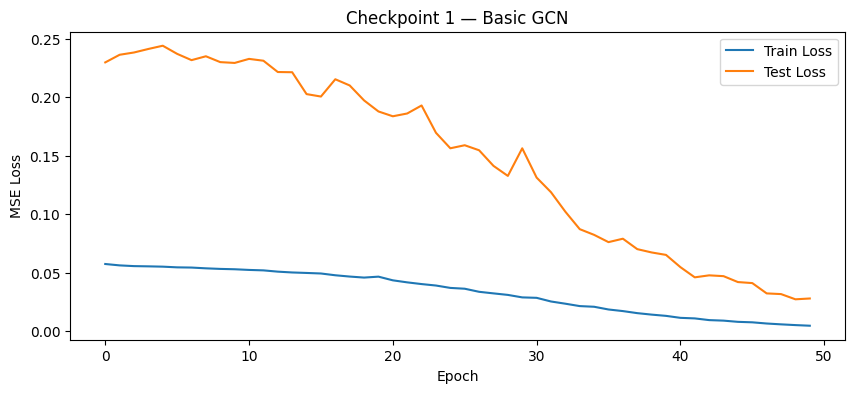

In [7]:
import matplotlib.pyplot as plt

train_losses, test_losses = [], []

for epoch in range(1, 51):
    model.train()
    total_loss = 0
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out  = model(batch)
        loss = criterion(out, batch.y)
        if torch.isnan(loss):
            continue
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
    train_loss = total_loss / len(train_loader)

    model.eval()
    total_test = 0
    with torch.no_grad():
        for batch in test_loader:
            batch = batch.to(device)
            out   = model(batch)
            total_test += criterion(out, batch.y).item()
    test_loss = total_test / len(test_loader)

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    if epoch % 5 == 0:
        print(f"Epoch {epoch:03d} | Train: {train_loss:.4f} | Test: {test_loss:.4f}")

plt.figure(figsize=(10,4))
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses,  label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Checkpoint 1 — Basic GCN')
plt.legend()
plt.savefig('/kaggle/working/checkpoint1_loss.png')
plt.show()

Correlation Skill Score: 0.9762
Test MSE: 0.0280


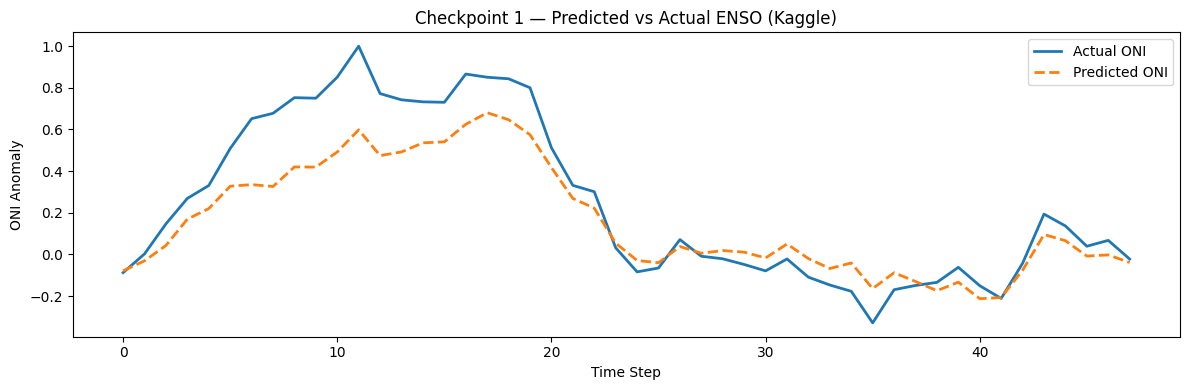

Model saved!


In [8]:
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

model.eval()
preds, actuals = [], []

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        out = model(batch)
        preds.extend(out.cpu().numpy())
        actuals.extend(batch.y.cpu().numpy())

preds   = np.array(preds)
actuals = np.array(actuals)

corr, _ = pearsonr(preds, actuals)
print(f"Correlation Skill Score: {corr:.4f}")
print(f"Test MSE: {np.mean((preds-actuals)**2):.4f}")

plt.figure(figsize=(12, 4))
plt.plot(actuals, label='Actual ONI', linewidth=2)
plt.plot(preds, label='Predicted ONI', linewidth=2, linestyle='--')
plt.xlabel('Time Step')
plt.ylabel('ONI Anomaly')
plt.title('Checkpoint 1 — Predicted vs Actual ENSO (Kaggle)')
plt.legend()
plt.tight_layout()
plt.savefig('/kaggle/working/checkpoint1_predictions.png')
plt.show()

# Save model permanently
torch.save(model.state_dict(), '/kaggle/working/checkpoint1_model.pth')
print("Model saved!")